## Data Loading and Initial Exploration
---
## Data Cleaning and Preprocessing
---
## Feature Engineering and Data Visualization
---
## Data Splitting and Scaling
---
## Model Selection and Hyperparameter Tuning
---
## Model Evaluation and Prediction Documentation

In [ ]:
import pandas as pd

In [ ]:
dataset = pd.read_csv('/content/All_Column_Dataset_Climate_change_indicators_for_pakistan.csv')

In [ ]:
dataset.head(4)

,Sno,Country Name,Year,Urban land area where elevation is below 5 meters (sq. km) Value,Ease of doing business rank (1=most business-friendly regulations) Value,CO2 intensity (kg per kg of oil equivalent energy use) Value,"Droughts, floods, extreme temperatures (% of population, average 1990-2009) Value",Total greenhouse gas emissions (% change from 1990) Value,CO2 emissions from solid fuel consumption (kt) Value,Cereal yield (kg per hectare) Value,...,"Prevalence of underweight, weight for age (% of children under 5) Value",CPIA public sector management and institutions cluster average (1=low to 6=high) Value,Rural land area where elevation is below 5 meters (sq. km) Value,CO2 emissions from liquid fuel consumption (% of total) Value,PFC gas emissions (thousand metric tons of CO2 equivalent) Value,HFC gas emissions (thousand metric tons of CO2 equivalent) Value,GHG net emissions/removals by LUCF (Mt of CO2 equivalent) Value,Agricultural land (% of land area) Value,Urban land area where elevation is below 5 meters (% of total land area) Value,RainFall Mean ()
0,1.0,Pakistan,1960.0,NaN,NaN,NaN,NaN,NaN,5892.869,NaN,...,NaN,NaN,NaN,46.295337,NaN,NaN,NaN,NaN,NaN,22.968764
1,2.0,Pakistan,1961.0,NaN,NaN,NaN,NaN,NaN,5804.861,856.4,...,NaN,NaN,NaN,46.785089,NaN,NaN,NaN,46.349626,NaN,30.017449
2,3.0,Pakistan,1962.0,NaN,NaN,NaN,NaN,NaN,6189.896,858.0,...,NaN,NaN,NaN,46.698543,NaN,NaN,NaN,46.492320,NaN,22.300155
3,4.0,Pakistan,1963.0,NaN,NaN,NaN,NaN,NaN,6681.274,877.7,...,NaN,NaN,NaN,48.385819,NaN,NaN,NaN,46.544209,NaN,18.846562


In [ ]:
dataset  = dataset.drop(['Sno','Country Name'], axis = 1)

In [ ]:
dataset.isna().sum()

,0
Year,1
Urban land area where elevation is below 5 meters (sq. km) Value,60
Ease of doing business rank (1=most business-friendly regulations) Value,62
CO2 intensity (kg per kg of oil equivalent energy use) Value,19
"Droughts, floods, extreme temperatures (% of population, average 1990-2009) Value",62
...,...
HFC gas emissions (thousand metric tons of CO2 equivalent) Value,58
GHG net emissions/removals by LUCF (Mt of CO2 equivalent) Value,62
Agricultural land (% of land area) Value,5
Urban land area where elevation is below 5 meters (% of total land area) Value,60


In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer
import pandas as pd

# Convert all columns to numeric, coercing errors to NaN
# This handles cases where numeric columns might contain non-numeric strings
for col in dataset.columns:
    dataset[col] = pd.to_numeric(dataset[col], errors='coerce')

# Drop columns that are entirely NaN after conversion
# This ensures the imputer doesn't implicitly change the number of columns,
# which caused the shape mismatch error.
dataset = dataset.dropna(axis=1, how='all')

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer = imputer.fit(dataset)
dataset = pd.DataFrame(imputer.transform(dataset), columns=dataset.columns)

In [ ]:
dataset.isna().sum()

,0
Year,0
Urban land area where elevation is below 5 meters (sq. km) Value,0
Ease of doing business rank (1=most business-friendly regulations) Value,0
CO2 intensity (kg per kg of oil equivalent energy use) Value,0
"Droughts, floods, extreme temperatures (% of population, average 1990-2009) Value",0
...,...
HFC gas emissions (thousand metric tons of CO2 equivalent) Value,0
GHG net emissions/removals by LUCF (Mt of CO2 equivalent) Value,0
Agricultural land (% of land area) Value,0
Urban land area where elevation is below 5 meters (% of total land area) Value,0


In [ ]:
print(dataset.columns)

Index(['Year',
       'Urban land area where elevation is below 5 meters (sq. km) Value',
       'Ease of doing business rank (1=most business-friendly regulations) Value',
       'CO2 intensity (kg per kg of oil equivalent energy use) Value',
       'Droughts, floods, extreme temperatures (% of population, average 1990-2009) Value',
       'Total greenhouse gas emissions (% change from 1990) Value',
       'CO2 emissions from solid fuel consumption (kt) Value',
       'Cereal yield (kg per hectare) Value',
       'CO2 emissions (kg per 2015 US$ of GDP) Value',
       'Community health workers (per 1,000 people) Value',
       'Average precipitation in depth (mm per year) Value',
       'Urban population growth (annual %) Value',
       'Population living in areas where elevation is below 5 meters (% of total population) Value',
       'Forest area (% of land area) Value',
       'Methane emissions (% change from 1990) Value',
       'Forest area (sq. km) Value',
       'Renewable ener

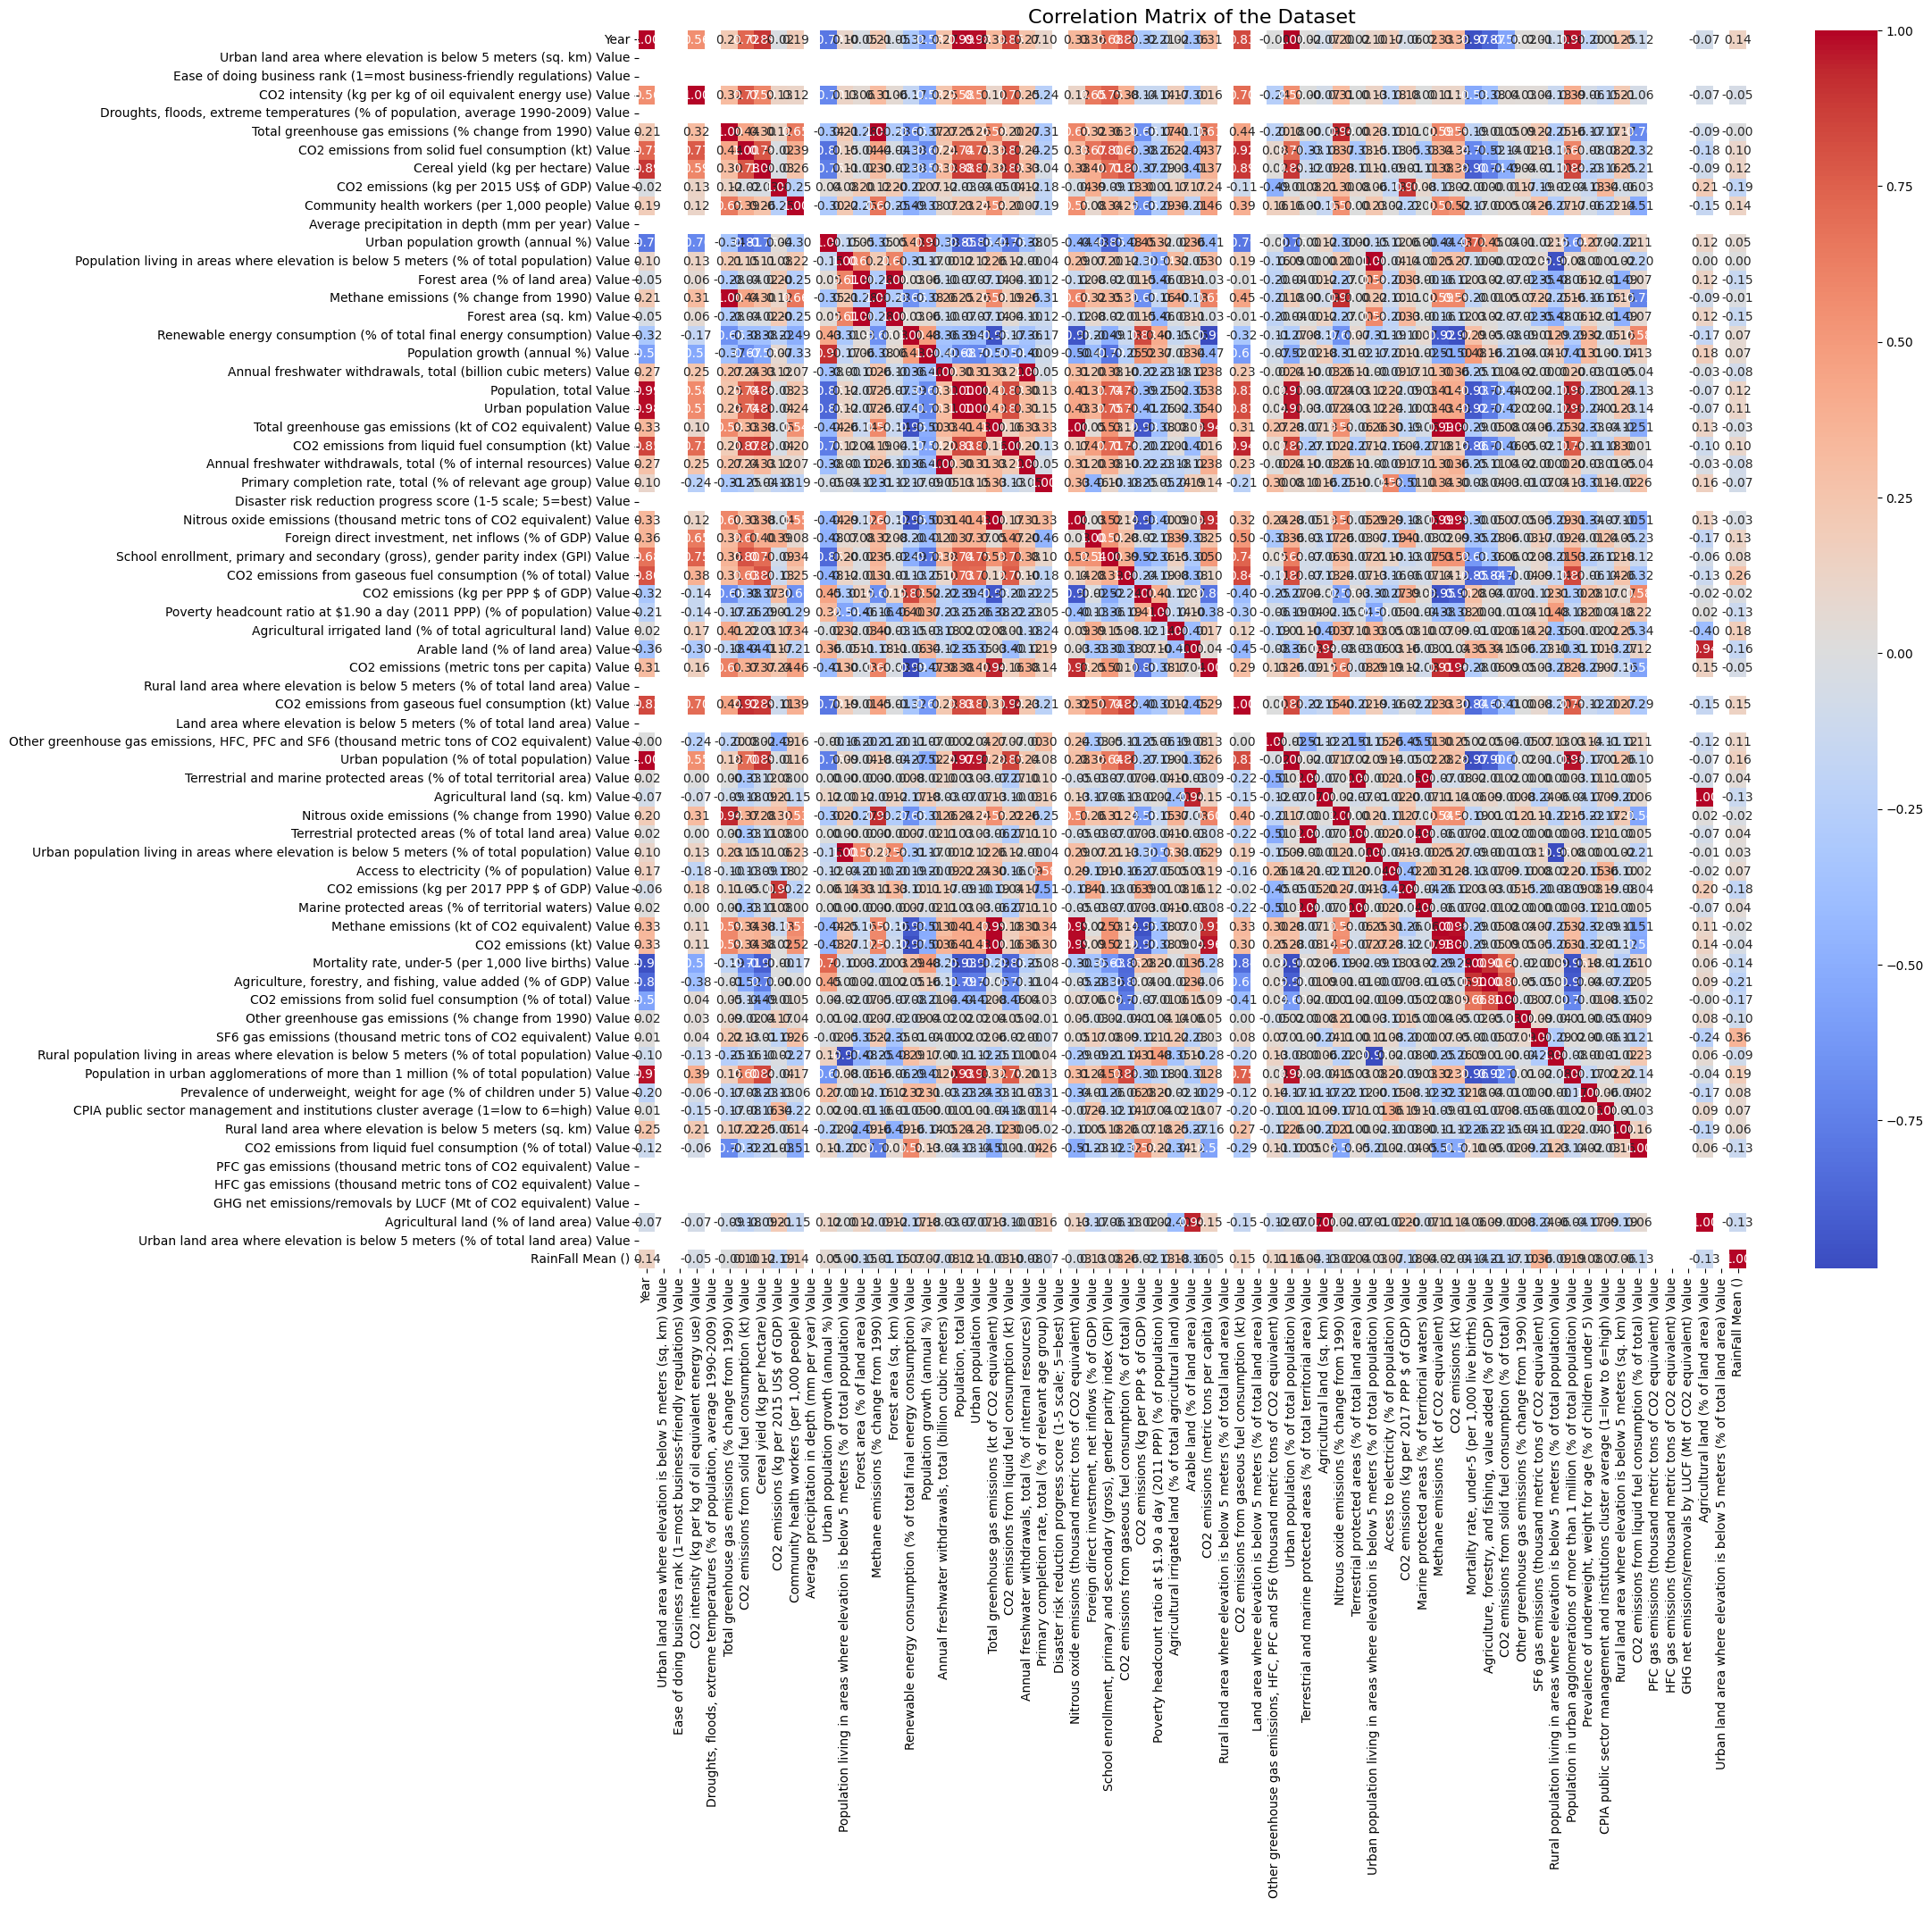

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 18))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of the Dataset', fontsize=16)
plt.show()

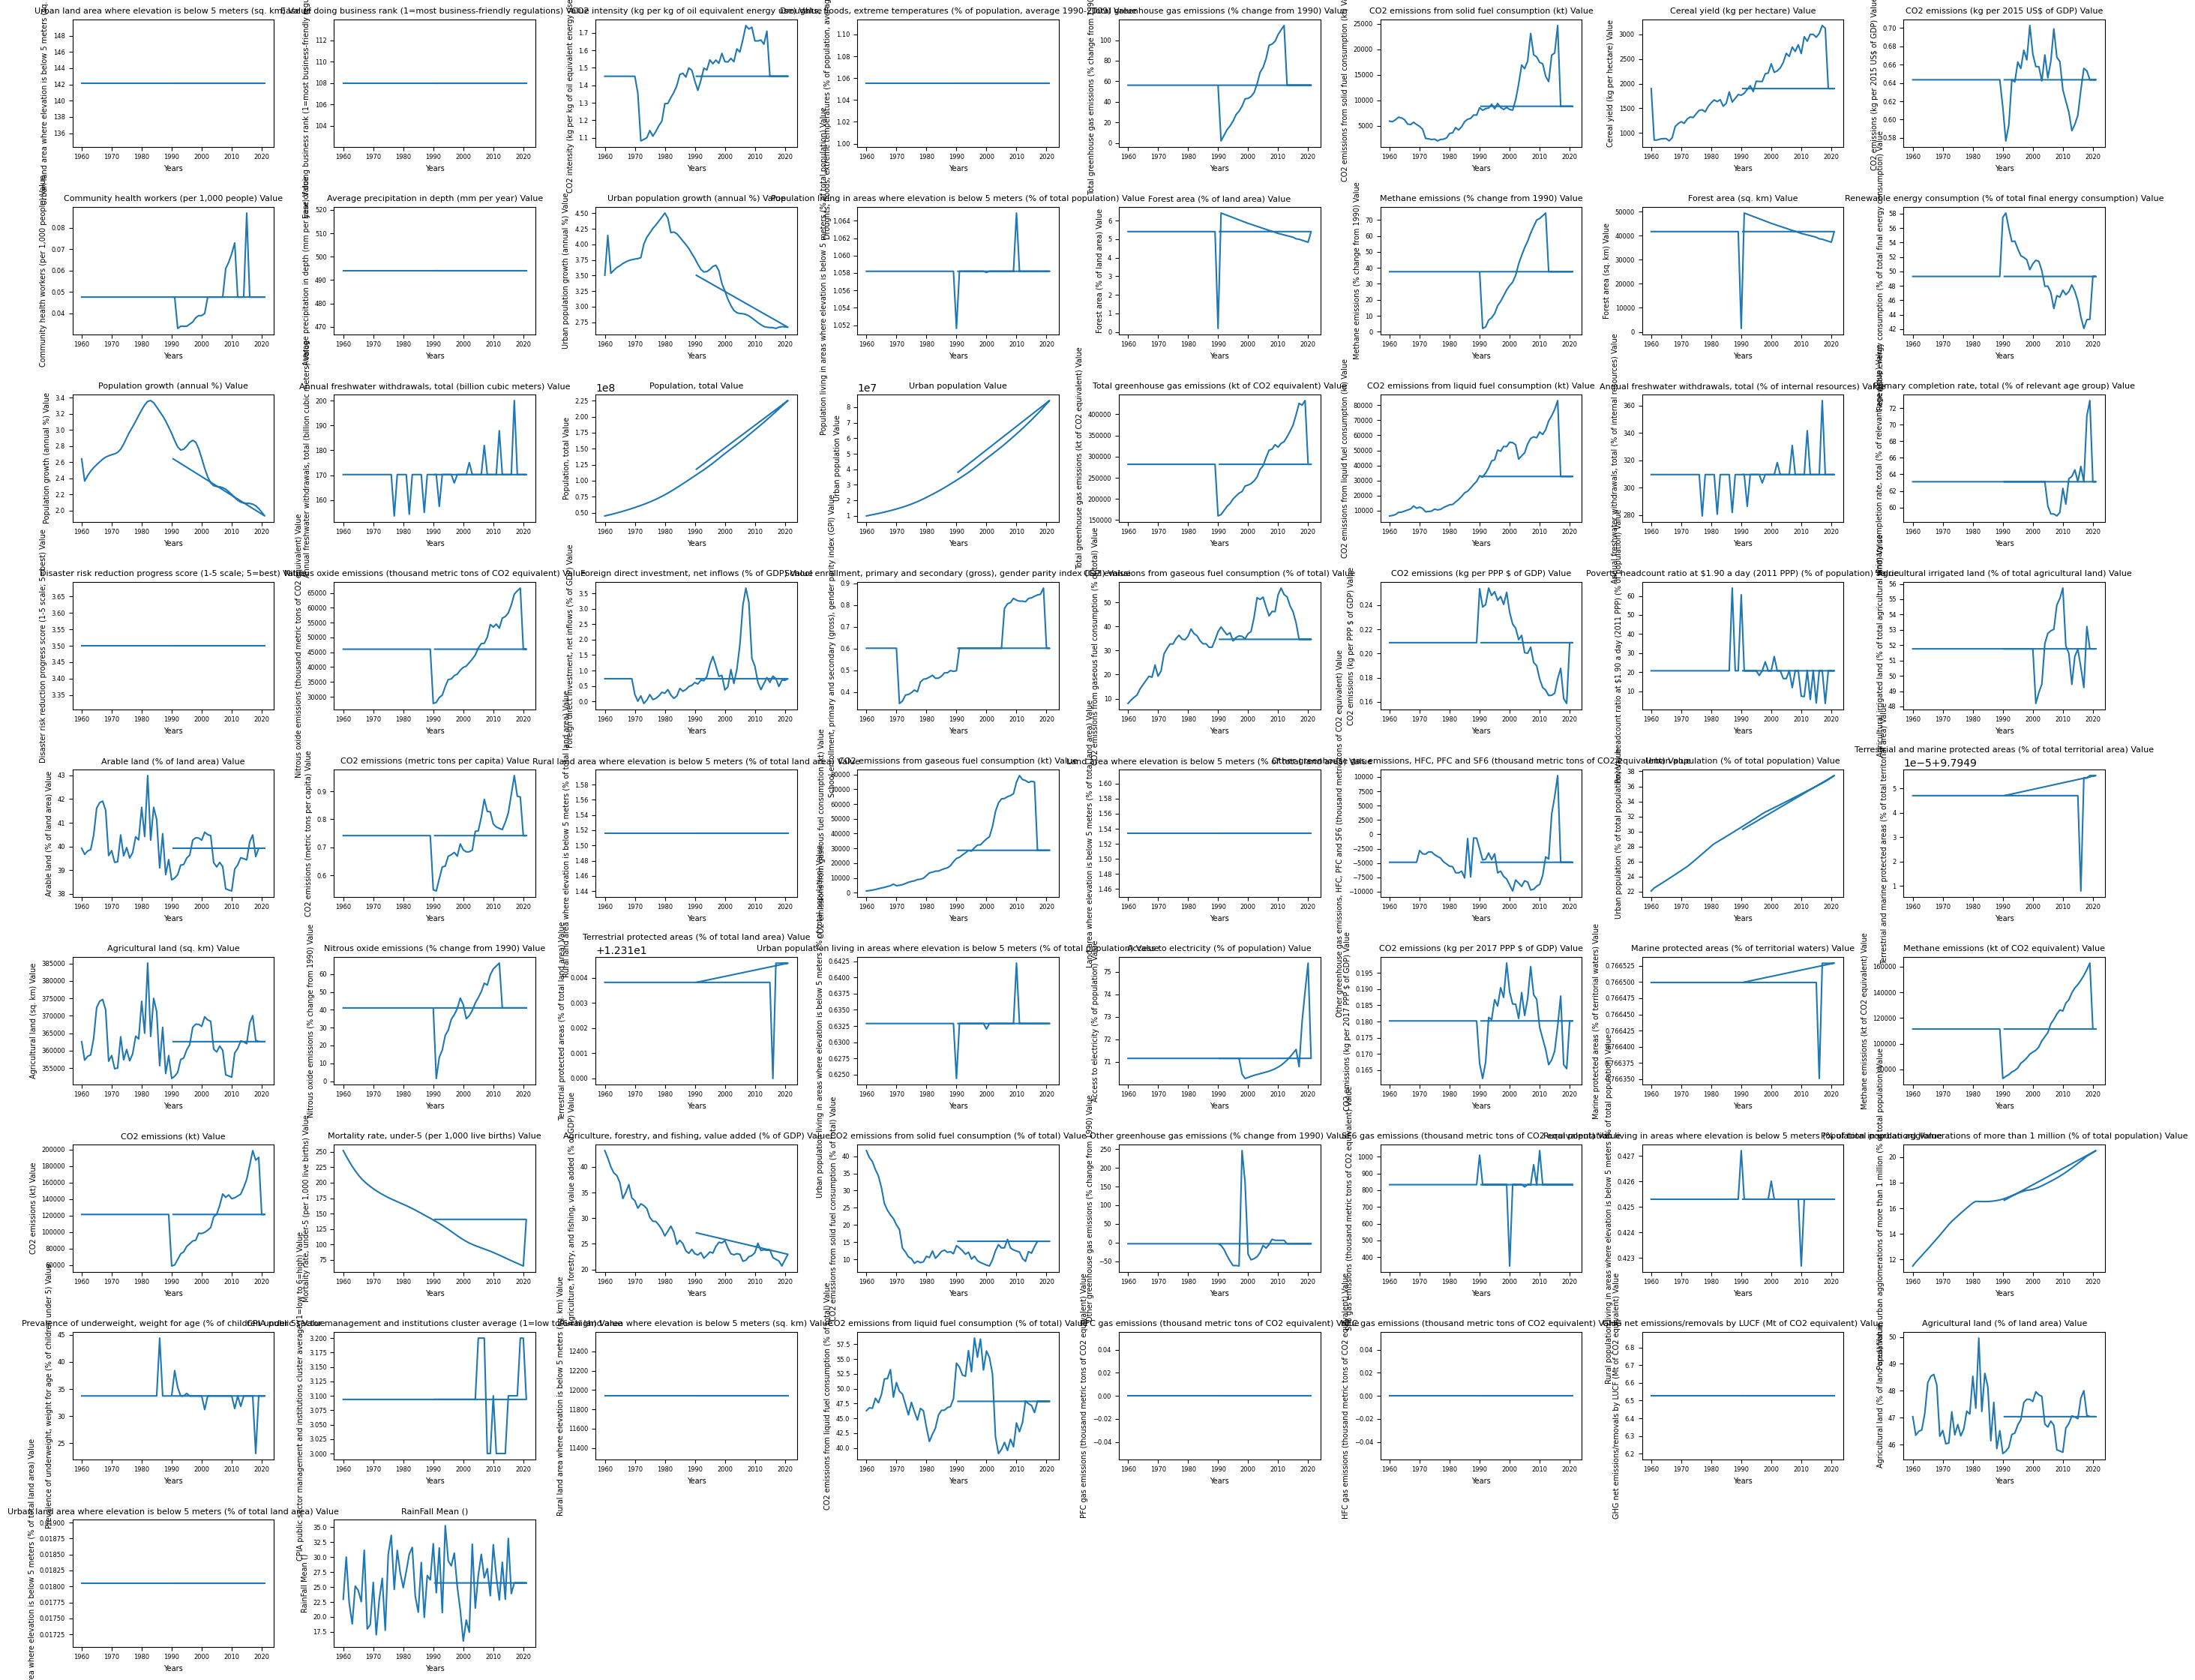

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get columns to plot (all except 'Year')
plot_cols = [col for col in dataset.columns if col != 'Year']
num_plots = len(plot_cols)

# Calculate grid dimensions for a more square-ish layout
nrows = int(np.ceil(np.sqrt(num_plots)))
ncols = int(np.ceil(num_plots / nrows))

# Create the figure and subplots with adjusted figsize for smaller graphs
# figsize will be roughly (width_per_plot * ncols, height_per_plot * nrows)
# Let's try 3 units width and 2 units height per plot as a starting point
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.5), dpi=100)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Iterate through columns and plot on each subplot
for i, col in enumerate(plot_cols):
    if i < len(axes): # Ensure we don't go out of bounds if num_plots < nrows*ncols
        ax = axes[i]
        ax.plot(dataset['Year'], dataset[col])
        ax.set_title(col, fontsize=8) # Smaller font for title
        ax.set_xlabel('Years', fontsize=7) # Smaller font for x-label
        ax.set_ylabel(col, fontsize=7) # Smaller font for y-label
        ax.tick_params(axis='both', which='major', labelsize=6) # Smaller tick labels

# Hide any unused subplots
for j in range(num_plots, len(axes)):
    if j < len(axes):
        fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

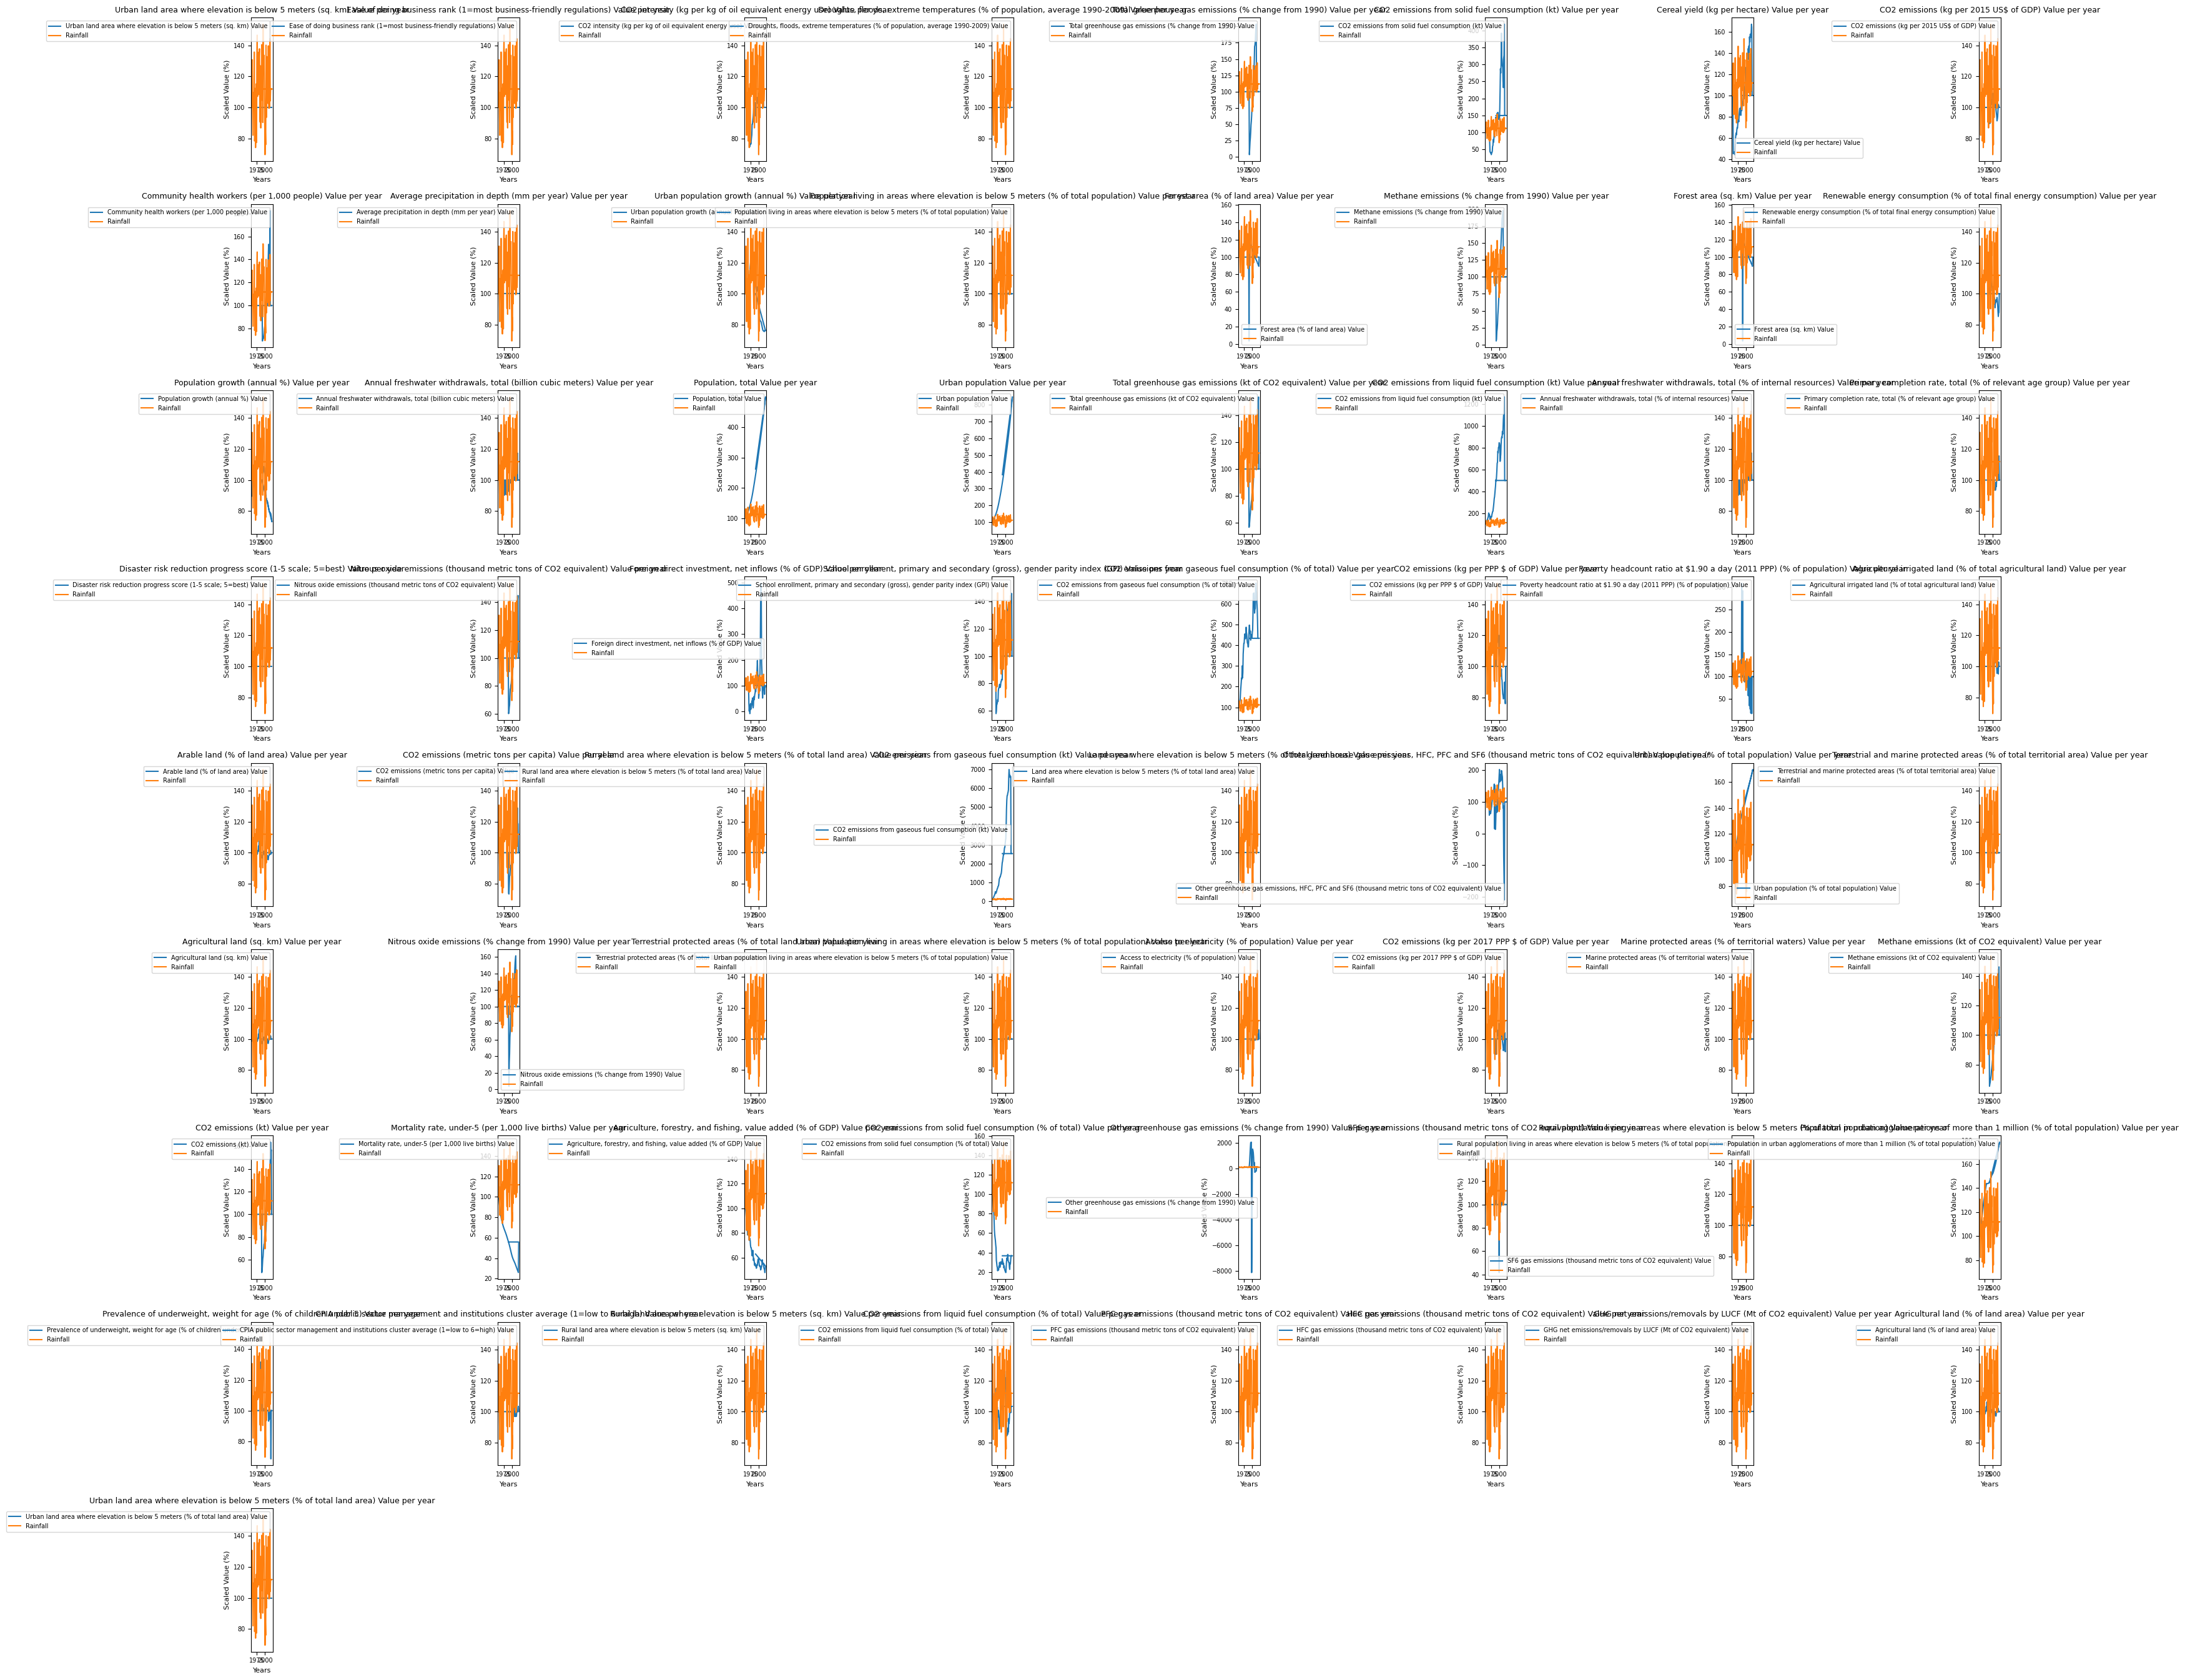

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get columns to plot (all except 'Year' and 'RainFall Mean ()')
plot_cols = [col for col in dataset.columns if col != 'Year' and col != 'RainFall Mean ()']
num_plots = len(plot_cols)

# Calculate grid dimensions for a more square-ish layout
nrows = int(np.ceil(np.sqrt(num_plots)))
ncols = int(np.ceil(num_plots / nrows))

# Create the figure and subplots with adjusted figsize for smaller graphs
# Let's try 4 units width and 3 units height per plot as a starting point
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), dpi=100)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Iterate through columns and plot on each subplot
for i, col in enumerate(plot_cols):
    if i < len(axes): # Ensure we don't go out of bounds if num_plots < nrows*ncols
        ax = axes[i]
        # Plot current column, scaled by its initial value
        ax.plot(dataset['Year'], dataset[col] / dataset[col].iloc[0] * 100, label=col)
        # Plot 'RainFall Mean ()', scaled by its initial value
        ax.plot(dataset['Year'], dataset['RainFall Mean ()'] / dataset['RainFall Mean ()'].iloc[0] * 100, label='Rainfall')
        ax.set_title(col + " per year", fontsize=9) # Smaller font for title
        ax.set_xlabel('Years', fontsize=8) # Smaller font for x-label
        ax.set_ylabel('Scaled Value (%)', fontsize=8) # Generic scaled label
        ax.tick_params(axis='both', which='major', labelsize=7) # Smaller tick labels
        ax.legend(fontsize=7)

# Hide any unused subplots
for j in range(num_plots, len(axes)):
    if j < len(axes):
        fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

<Axes: >

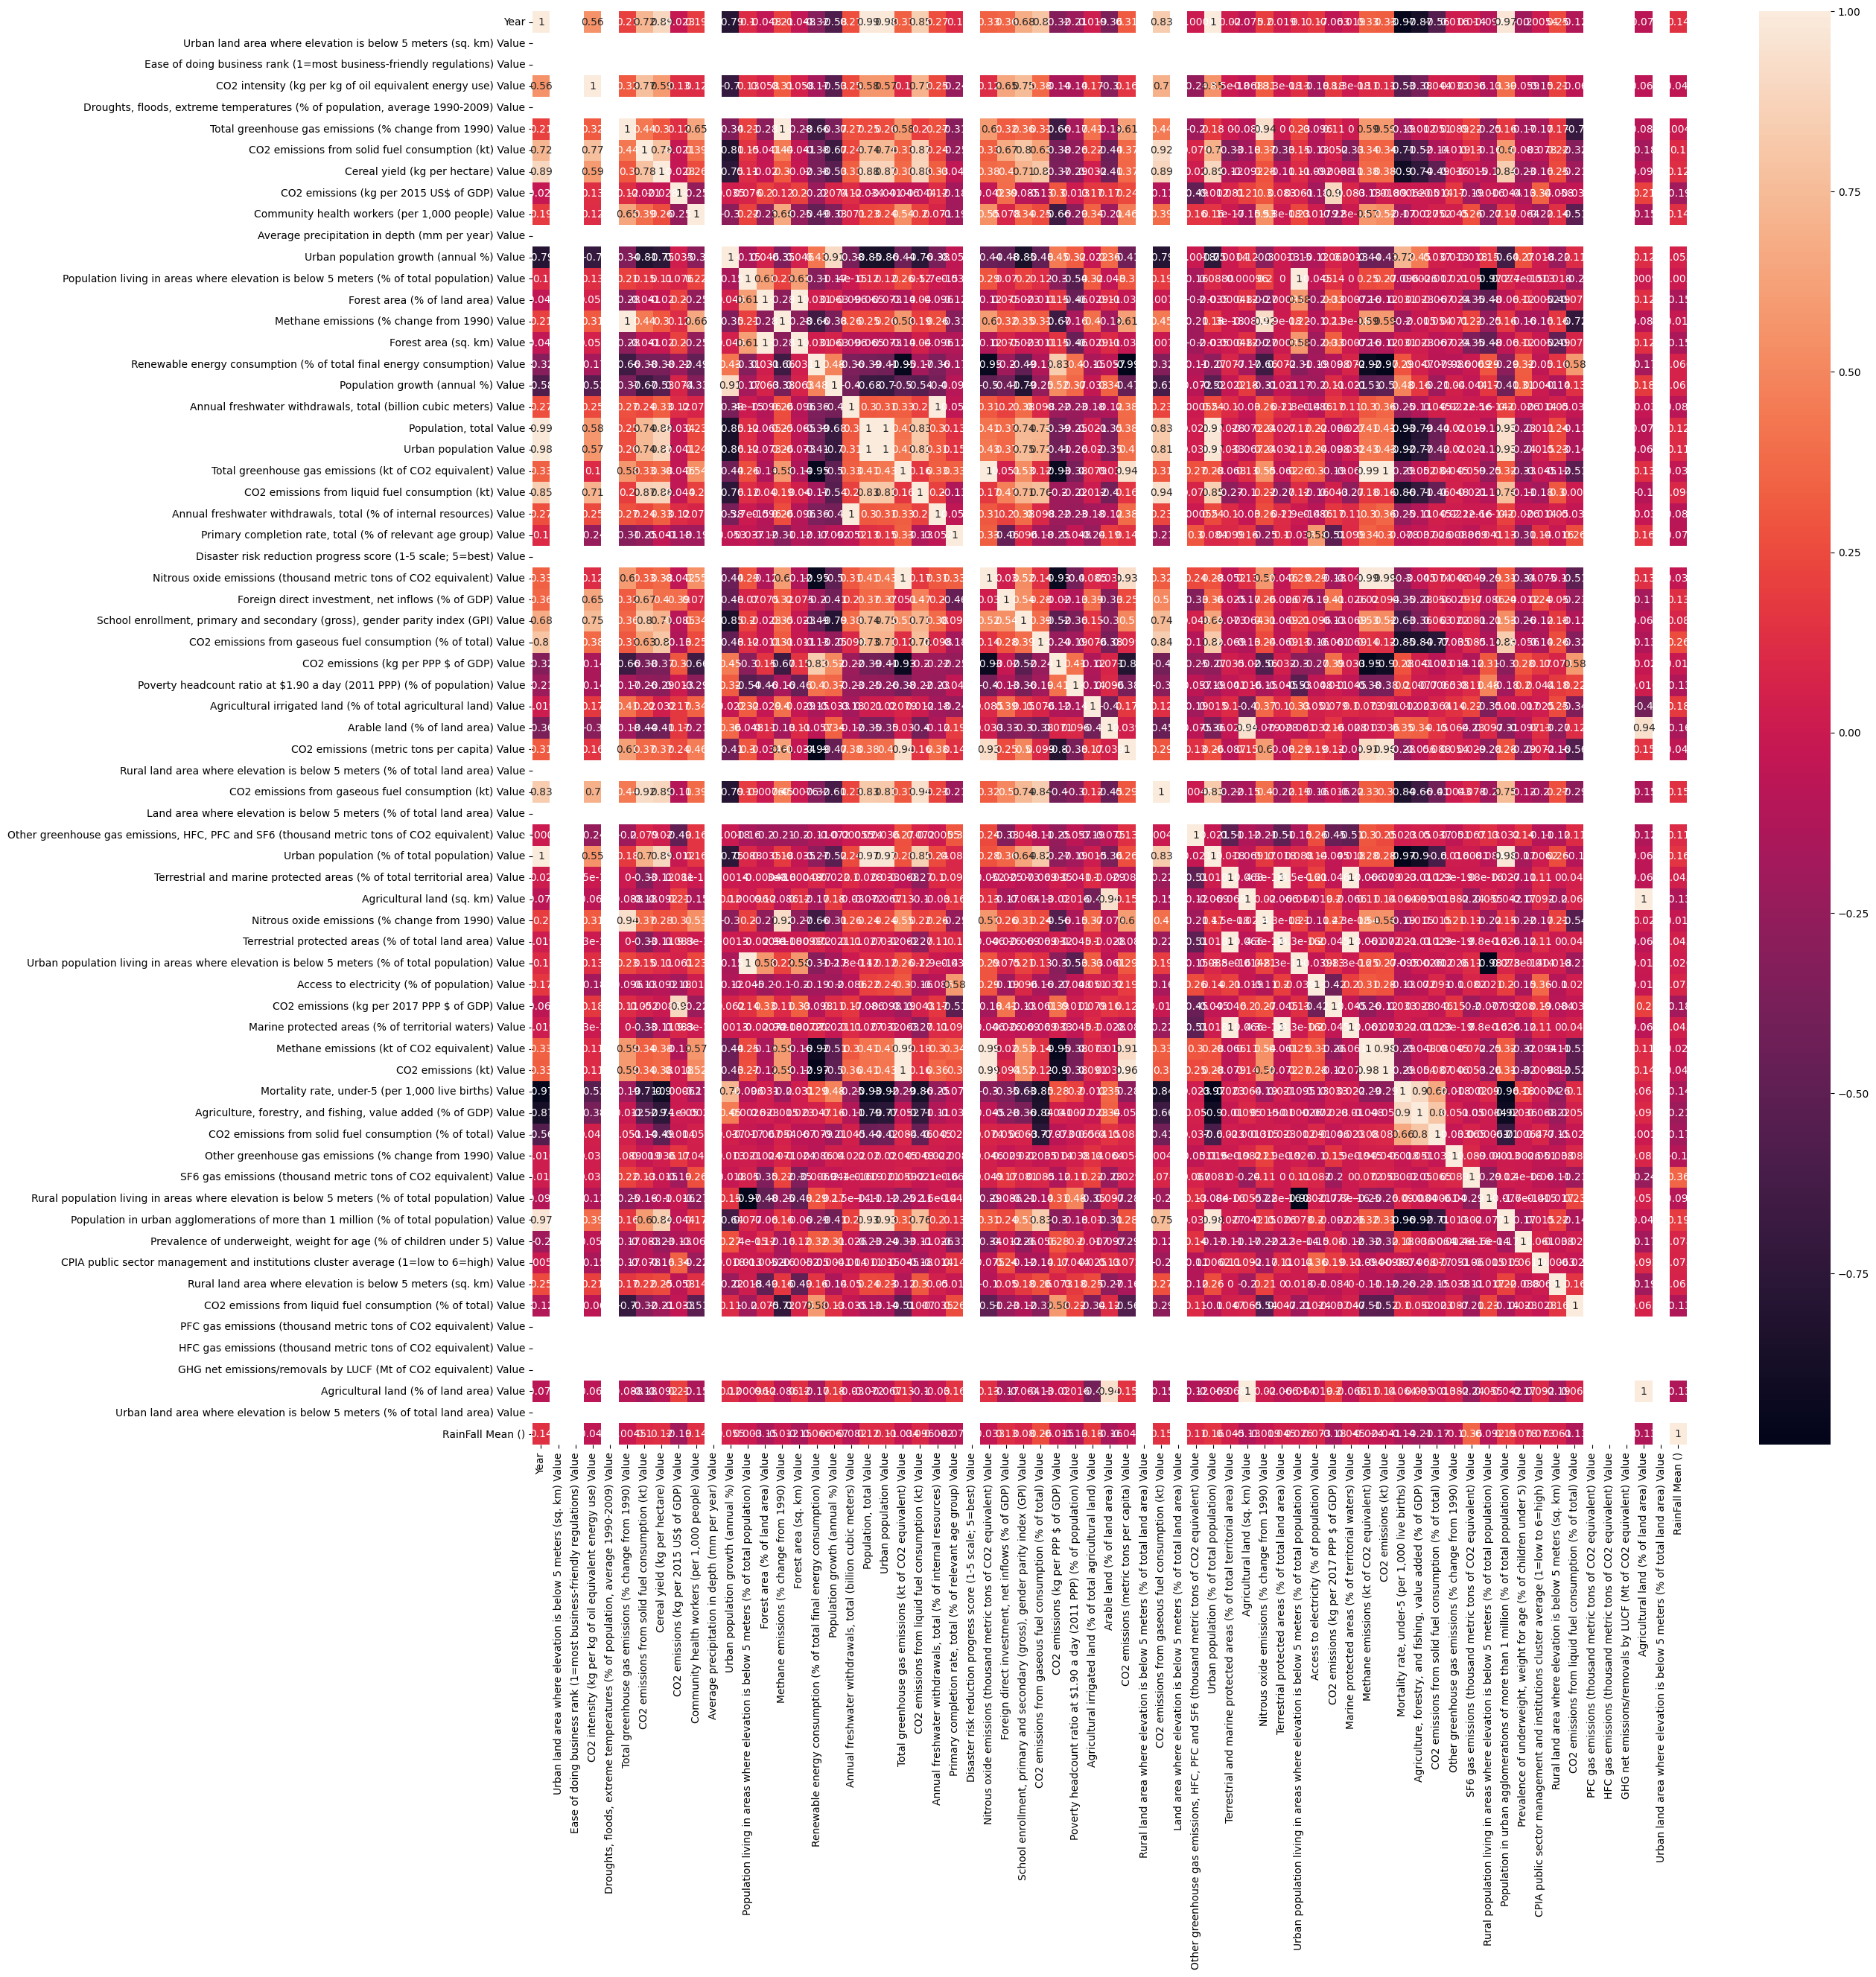

In [ ]:
import seaborn as sns
fig, ax = plt.subplots(figsize = (25, 25))
sns.heatmap(dataset.corr(), annot = True)

In [ ]:
X = dataset.drop(['Year','RainFall Mean ()'],axis = 1)
y = dataset['RainFall Mean ()']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state = 0)

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
def evaluate(y_test,pred):
    return {
        "R2":r2_score(y_test,pred),
        "MAE":mean_absolute_error(y_test,pred),
        "MSE":mean_squared_error(y_test,pred),
    }

### Data Scaling

Before hyperparameter tuning, it's often beneficial to scale the data. Scaling ensures that all features contribute equally to the distance calculations in algorithms like K-Nearest Neighbors and can help stabilize models like Ridge Regression.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for consistency and to retain column names if needed later
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Data scaled successfully!")

Data scaled successfully!


### Hyperparameter Tuning for KNeighborsRegressor

Now, let's fine-tune the `KNeighborsRegressor` using `GridSearchCV`. This will search for the best `n_neighbors` parameter by evaluating different values using cross-validation.

Best parameters for KNeighborsRegressor: {'n_neighbors': 9, 'weights': 'uniform'}
Best R2 score for KNeighborsRegressor: -0.1792

KNeighborsRegressor (Tuned) Evaluation:
{'R2': -0.1324278747067793, 'MAE': 3.5777941159904034, 'MSE': 23.80537120080094}


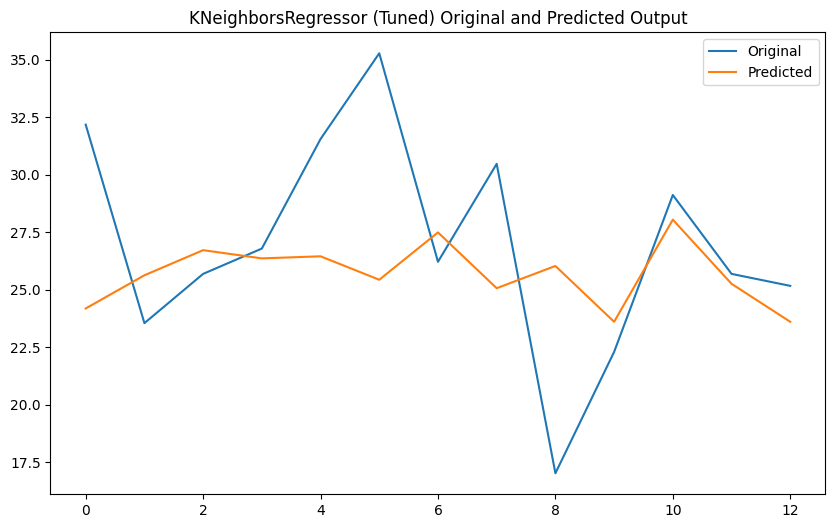

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

# Define the parameter grid for KNeighborsRegressor
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance']
}

knn_model = KNeighborsRegressor()

grid_search_knn = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid_knn,
    scoring='r2', # Using R2 as the scoring metric
    cv=5,         # 5-fold cross-validation
    n_jobs=-1     # Use all available CPU cores
)

# Fit GridSearchCV on the scaled training data
grid_search_knn.fit(X_train_scaled, y_train)

print(f"Best parameters for KNeighborsRegressor: {grid_search_knn.best_params_}")
print(f"Best R2 score for KNeighborsRegressor: {grid_search_knn.best_score_:.4f}")

# Evaluate the best KNN model on the scaled test data
best_knn_model = grid_search_knn.best_estimator_
pred_knn = best_knn_model.predict(X_test_scaled)
scores_knn = evaluate(y_test, pred_knn)

print("\nKNeighborsRegressor (Tuned) Evaluation:")
print(scores_knn)

# Plotting for the best KNN model
plt.figure(figsize=(10, 6))
plt.plot(list(y_test), label='Original')
plt.plot(pred_knn, label='Predicted')
plt.legend()
plt.title('KNeighborsRegressor (Tuned) Original and Predicted Output')
plt.show()

### Hyperparameter Tuning for Ridge Regression

Next, let's fine-tune the `Ridge Regressor` using `GridSearchCV` to find the best `alpha` parameter, which controls the strength of the L2 regularization.

Best parameters for Ridge Regression: {'alpha': 100.0, 'solver': 'lsqr'}
Best R2 score for Ridge Regression: -0.2135

Ridge Regression (Tuned) Evaluation:
{'R2': -0.20953022000562038, 'MAE': 3.724880868673126, 'MSE': 25.426180782838554}


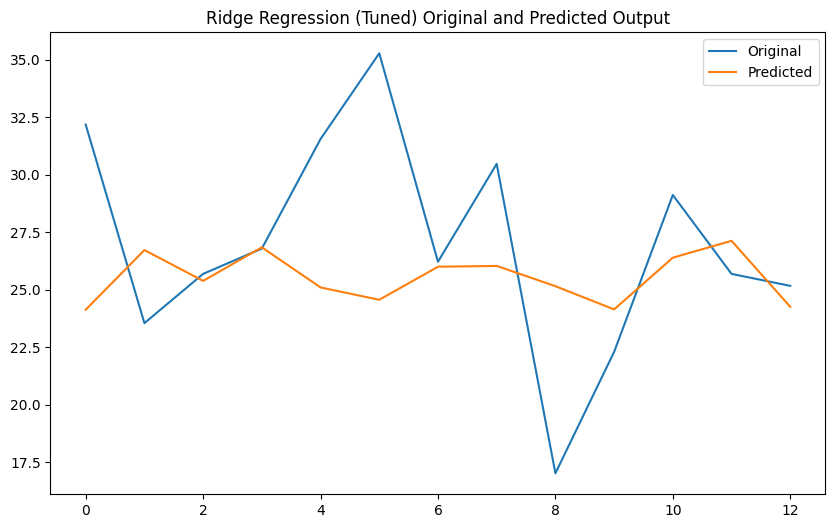

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Ridge Regression
param_grid_ridge = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag', 'saga'] # Explore different solvers for robustness
}

ridge_model = Ridge(random_state=42) # Added random_state for reproducibility with 'sag' or 'saga' solvers

grid_search_ridge = GridSearchCV(
    estimator=ridge_model,
    param_grid=param_grid_ridge,
    scoring='r2', # Using R2 as the scoring metric
    cv=5,         # 5-fold cross-validation
    n_jobs=-1     # Use all available CPU cores
)

# Fit GridSearchCV on the scaled training data
grid_search_ridge.fit(X_train_scaled, y_train)

print(f"Best parameters for Ridge Regression: {grid_search_ridge.best_params_}")
print(f"Best R2 score for Ridge Regression: {grid_search_ridge.best_score_:.4f}")

# Evaluate the best Ridge model on the scaled test data
best_ridge_model = grid_search_ridge.best_estimator_
pred_ridge = best_ridge_model.predict(X_test_scaled)
scores_ridge = evaluate(y_test, pred_ridge)

print("\nRidge Regression (Tuned) Evaluation:")
print(scores_ridge)

# Plotting for the best Ridge model
plt.figure(figsize=(10, 6))
plt.plot(list(y_test), label='Original')
plt.plot(pred_ridge, label='Predicted')
plt.legend()
plt.title('Ridge Regression (Tuned) Original and Predicted Output')
plt.show()

### Predicting and Visualizing Sample Examples

Let's take a few examples from the test set and see how our best-tuned `KNeighborsRegressor` predicts their rainfall values compared to the actual values.

Sample Predictions (Actual vs. Predicted):


,Actual Rainfall,Predicted Rainfall
0,32.173924,24.188020
1,23.550433,25.629704
2,25.690321,26.720699
3,26.790030,26.363131
4,31.548378,26.453863


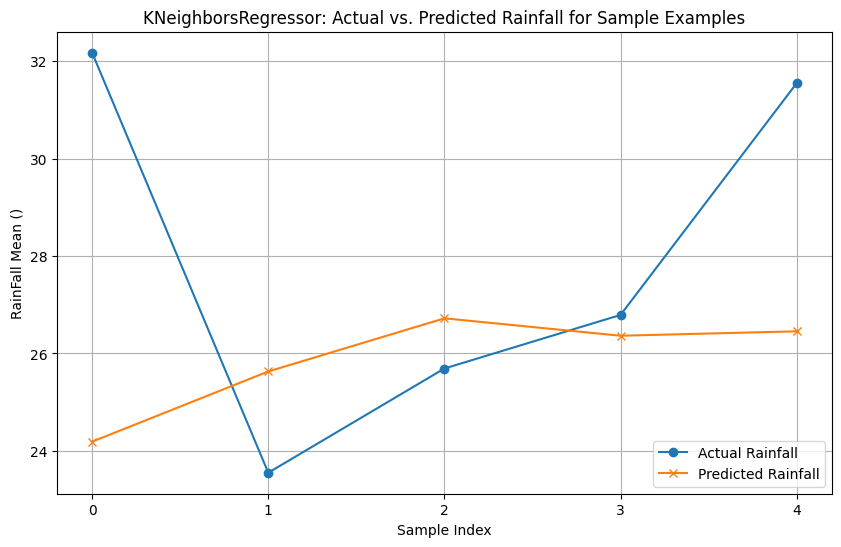

In [ ]:
# Select a few sample indices from the test set to predict
sample_indices = [0, 1, 2, 3, 4] # Using the first 5 samples from X_test_scaled

# Get the actual data points and their corresponding labels
sample_X = X_test_scaled.iloc[sample_indices]
sample_y_actual = y_test.iloc[sample_indices]

# Use the best tuned KNN model to make predictions on these samples
sample_y_predicted = best_knn_model.predict(sample_X)

# Create a DataFrame to display actual vs. predicted values
predictions_df = pd.DataFrame({
    'Actual Rainfall': sample_y_actual.values,
    'Predicted Rainfall': sample_y_predicted
})

print("Sample Predictions (Actual vs. Predicted):")
display(predictions_df)

# Plotting the sample predictions
plt.figure(figsize=(10, 6))
plt.plot(sample_y_actual.values, label='Actual Rainfall', marker='o')
plt.plot(sample_y_predicted, label='Predicted Rainfall', marker='x')
plt.title('KNeighborsRegressor: Actual vs. Predicted Rainfall for Sample Examples')
plt.xlabel('Sample Index')
plt.ylabel('RainFall Mean ()')
plt.xticks(ticks=range(len(sample_indices)), labels=sample_indices)
plt.legend()
plt.grid(True)
plt.show()

### Predicting Rainfall for a Future Year (2026)

To predict rainfall for a future year like 2026, we need to provide values for all the input features (`X`) for that specific year. Since we do not have actual data for 2026, we will make an assumption for the feature values. A common approach for a baseline prediction is to use the mean of each feature from the training dataset. This means the model will predict based on 'average' conditions as learned from the historical data.

It is crucial to remember that this is an **extrapolation** and the accuracy will be highly dependent on how well these average conditions reflect the actual future state and the model's overall predictive power, which has been low so far.

In [ ]:
import pandas as pd

# User-provided data for 2026
data = {
    "Year": [2026],
    "Urban land area below 5m (sq. km)": [3200],
    "Ease of doing business rank": [110],
    "CO2 intensity (kg per kg of oil eq)": [0.14],
    "Population affected by disasters (%)": [3.5],
    "GHG emissions change from 1990 (%)": [140],
    "CO2 emissions solid fuel (kt)": [18500],
    "Cereal yield (kg per hectare)": [3250],
    "CO2 emissions per GDP (kg per 2015 USD)": [0.18],
    "Community health workers (per 1000)": [1.1],
    "Precipitation (mm per year)": [500],
    "Urban population growth (%)": [2.7],
    "Population in low elevation (%)": [10.5],
    "Forest area (%)": [4.8],
    "Methane emissions change (%)": [120],
    "Forest area (sq. km)": [47500],
    "Renewable energy consumption (%)": [9],
    "Population growth (%)": [1.9],
    "Freshwater withdrawals (billion m3)": [70],
    "Population total": [248_000_000],
    "Urban population": [98_000_000],
    "Total GHG emissions (kt CO2 eq)": [540000],
    "CO2 liquid fuel (kt)": [120000],
    "Water withdrawals (% internal resources)": [330],
    "Primary completion rate (%)": [76],
    "Disaster risk score (1-5)": [2.8],
    "Nitrous oxide emissions (kt CO2 eq)": [38000],
    "FDI inflows (% GDP)": [1.5],
    "School GPI": [0.95],
    "CO2 gas fuel (%)": [35],
    "CO2 per PPP GDP (kg)": [0.25],
    "Poverty rate (%)": [5.5],
    "Irrigated land (%)": [80],
    "Arable land (%)": [39],
    "CO2 per capita (tons)": [0.9],
    "Rural low elevation land (%)": [4],
    "CO2 gas (kt)": [70000],
    "Low elevation land (%)": [5],
    "Other GHG (HFC/PFC/SF6) (kt CO2 eq)": [9000],
    "Urban population (%)": [39.5],
    "Protected areas (%)": [15.5],
    "Agricultural land (sq. km)": [370000],
    "Nitrous oxide change (%)": [110],
    "Terrestrial protected areas (%)": [14],
    "Urban low elevation population (%)": [8],
    "Access to electricity (%)": [97],
    "CO2 per PPP (2017) (kg)": [0.20],
    "Marine protected areas (%)": [1.2],
    "Methane emissions (kt CO2 eq)": [220000],
    "CO2 total (kt)": [210000],
    "Under-5 mortality (per 1000)": [55],
    "Agriculture share GDP (%)": [22],
    "CO2 solid fuel (%)": [9],
    "Other GHG change (%)": [90],
    "SF6 emissions (kt CO2 eq)": [500],
    "Rural low elevation population (%)": [3],
    "Population in cities >1M (%)": [28],
    "Underweight children (%)": [22],
    "CPIA score": [3.1],
    "Rural low elevation land (sq. km)": [8500],
    "CO2 liquid fuel (%)": [58],
    "PFC emissions (kt CO2 eq)": [1500],
    "HFC emissions (kt CO2 eq)": [7000],
    "LUCF net emissions (Mt CO2 eq)": [-5],
    "Agricultural land (%)": [47],
    "Urban low elevation land (%)": [2],
    "Rainfall mean (mm)": [500]
}

user_input_df = pd.DataFrame(data)

# Define a mapping from user-friendly column names to model feature names
column_mapping = {
    "Urban land area below 5m (sq. km)": "Urban land area where elevation is below 5 meters (sq. km) Value",
    "Ease of doing business rank": "Ease of doing business rank (1=most business-friendly regulations) Value",
    "CO2 intensity (kg per kg of oil eq)": "CO2 intensity (kg per kg of oil equivalent energy use) Value",
    "Population affected by disasters (%)": "Droughts, floods, extreme temperatures (% of population, average 1990-2009) Value",
    "GHG emissions change from 1990 (%)": "Total greenhouse gas emissions (% change from 1990) Value",
    "CO2 emissions solid fuel (kt)": "CO2 emissions from solid fuel consumption (kt) Value",
    "Cereal yield (kg per hectare)": "Cereal yield (kg per hectare) Value",
    "CO2 emissions per GDP (kg per 2015 USD)": "CO2 emissions (kg per 2015 US$ of GDP) Value",
    "Community health workers (per 1000)": "Community health workers (per 1,000 people) Value",
    "Precipitation (mm per year)": "Average precipitation in depth (mm per year) Value",
    "Urban population growth (%)": "Urban population growth (annual %) Value",
    "Population in low elevation (%)": "Population living in areas where elevation is below 5 meters (% of total population) Value",
    "Forest area (%)": "Forest area (% of land area) Value",
    "Methane emissions change (%)": "Methane emissions (% change from 1990) Value",
    "Forest area (sq. km)": "Forest area (sq. km) Value",
    "Renewable energy consumption (%)": "Renewable energy consumption (% of total final energy consumption) Value",
    "Population growth (%)": "Population growth (annual %) Value",
    "Freshwater withdrawals (billion m3)": "Annual freshwater withdrawals, total (billion cubic meters) Value",
    "Population total": "Population, total Value",
    "Urban population": "Urban population Value",
    "Total GHG emissions (kt CO2 eq)": "Total greenhouse gas emissions (kt of CO2 equivalent) Value",
    "CO2 liquid fuel (kt)": "CO2 emissions from liquid fuel consumption (kt) Value",
    "Water withdrawals (% internal resources)": "Annual freshwater withdrawals, total (% of internal resources) Value",
    "Primary completion rate (%)": "Primary completion rate, total (% of relevant age group) Value",
    "Disaster risk score (1-5)": "Disaster risk reduction progress score (1-5 scale; 5=best) Value",
    "Nitrous oxide emissions (kt CO2 eq)": "Nitrous oxide emissions (thousand metric tons of CO2 equivalent) Value",
    "FDI inflows (% GDP)": "Foreign direct investment, net inflows (% of GDP) Value",
    "School GPI": "School enrollment, primary and secondary (gross), gender parity index (GPI) Value",
    "CO2 gas fuel (%)": "CO2 emissions from gaseous fuel consumption (% of total) Value",
    "CO2 per PPP GDP (kg)": "CO2 emissions (kg per PPP $ of GDP) Value",
    "Poverty rate (%)": "Poverty headcount ratio at $1.90 a day (2011 PPP) (% of population) Value",
    "Irrigated land (%)": "Irrigated agricultural land (% of total agricultural land) Value",
    "Arable land (%)": "Arable land (% of land area) Value",
    "CO2 per capita (tons)": "CO2 emissions per capita (metric tons) Value",
    "Rural low elevation land (%)": "Rural land area where elevation is below 5 meters (% of total land area) Value",
    "CO2 gas (kt)": "CO2 emissions from gaseous fuel consumption (kt) Value",
    "Low elevation land (%)": "Population living in areas where elevation is below 5 meters (% of total land area) Value",
    "Other GHG (HFC/PFC/SF6) (kt CO2 eq)": "Other greenhouse gas emissions (thousand metric tons of CO2 equivalent) Value",
    "Urban population (%)": "Urban population (% of total population) Value",
    "Protected areas (%)": "Terrestrial and marine protected areas (% of total territorial area) Value",
    "Agricultural land (sq. km)": "Agricultural land (sq. km) Value",
    "Nitrous oxide change (%)": "Nitrous oxide emissions (% change from 1990) Value",
    "Terrestrial protected areas (%)": "Terrestrial protected areas (% of total land area) Value",
    "Urban low elevation population (%)": "Urban population living in areas where elevation is below 5 meters (% of total population) Value",
    "Access to electricity (%)": "Access to electricity (% of population) Value",
    "CO2 per PPP (2017) (kg)": "CO2 emissions (kg per 2017 PPP $ of GDP) Value",
    "Marine protected areas (%)": "Marine protected areas (% of territorial waters) Value",
    "Methane emissions (kt CO2 eq)": "Methane emissions (kt of CO2 equivalent) Value",
    "CO2 total (kt)": "CO2 emissions (kt) Value",
    "Under-5 mortality (per 1000)": "Mortality rate, under-5 (per 1,000 live births) Value",
    "Agriculture share GDP (%)": "Agriculture, forestry, and fishing, value added (% of GDP) Value",
    "CO2 solid fuel (%)": "CO2 emissions from solid fuel consumption (% of total) Value",
    "Other GHG change (%)": "Other greenhouse gas emissions (% change from 1990) Value",
    "SF6 emissions (kt CO2 eq)": "SF6 gas emissions (thousand metric tons of CO2 equivalent) Value",
    "Rural low elevation population (%)": "Rural population living in areas where elevation is below 5 meters (% of total population) Value",
    "Population in cities >1M (%)": "Population in urban agglomerations of more than 1 million (% of total population) Value",
    "Underweight children (%)": "Prevalence of underweight, weight for age (% of children under 5) Value",
    "CPIA score": "CPIA public sector management and institutions cluster average (1=low to 6=high) Value",
    "Rural low elevation land (sq. km)": "Rural land area where elevation is below 5 meters (sq. km) Value",
    "CO2 liquid fuel (%)": "CO2 emissions from liquid fuel consumption (% of total) Value",
    "PFC emissions (kt CO2 eq)": "PFC gas emissions (thousand metric tons of CO2 equivalent) Value",
    "HFC emissions (kt CO2 eq)": "HFC gas emissions (thousand metric tons of CO2 equivalent) Value",
    "LUCF net emissions (Mt CO2 eq)": "GHG net emissions/removals by LUCF (Mt of CO2 equivalent) Value",
    "Agricultural land (%)": "Agricultural land (% of land area) Value",
    "Urban low elevation land (%)": "Urban land area where elevation is below 5 meters (% of total land area) Value"
}

# Create a Series for 2026 features, initialized with X_train means
X_2026_custom_series = X_train.mean().copy()

# Update with user-provided values using the mapping
for user_col, model_col in column_mapping.items():
    if user_col in user_input_df.columns and model_col in X_2026_custom_series.index:
        X_2026_custom_series[model_col] = user_input_df[user_col].iloc[0]

# Convert the Series to a DataFrame with the correct year as index
X_2026_custom_df = pd.DataFrame([X_2026_custom_series], index=[user_input_df['Year'].iloc[0]])

# Ensure column order matches X_train
X_2026_custom_df = X_2026_custom_df[X_train.columns]

# Scale this new data point using the previously fitted scaler
X_2026_scaled = scaler.transform(X_2026_custom_df)
X_2026_scaled_df = pd.DataFrame(X_2026_scaled, columns=X_train.columns, index=X_2026_custom_df.index)

# Predict rainfall for 2026 using the best-tuned KNeighborsRegressor
predicted_rainfall_2026 = best_knn_model.predict(X_2026_scaled_df)

print(f"Predicted Rainfall for {int(X_2026_custom_df.index[0])}: {predicted_rainfall_2026[0]:.2f} units")

Predicted Rainfall for 2026: 26.11 units
